2. Data Preparation

This notebook will prepare the data for machine learning:
- download card images
- resize to 120x168 RGB (width x height)
- map the rarities to 5 classes
- handle class imbalance 
- one-hot encode labels
- save prepared data to disk

In [11]:
import sys
sys.path.insert(0, '..')

from data.dataset import Dataset
from data.rarity_classes import RARITY_CLASSES
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
print(os.getcwd())

/Users/markusgarmeister/Desktop/ML_PokeCard/notebooks


2.1 Load mapped Data

First we load the data with our mapped rarity. In the dataset are about ~300 cards, which have no rarity label. In the data exploration I inspected a few of them, in order to see if there is a certain pattern or kind of card. However from my investigation it looks like there are all kind of cards in there (energy, promo, common, ...). Therefore I decided to neglect theim, since it just a small part of the over 18,000 cards.

Total cards in dataset with rarity label: 17915

Class distribution:
mapped_rarity
Rare           5189
Common         4632
Uncommon       4407
Ultra Rare     2328
Secret Rare    1359
Name: count, dtype: int64


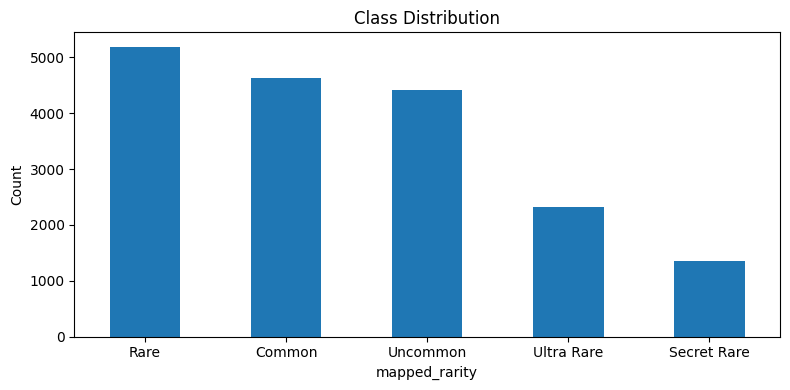

In [2]:
dataset = Dataset()
df = dataset.get_mapped_dataset()
df = df[df['mapped_rarity'].notna()]
print(f"Total cards in dataset with rarity label: {len(df)}")
print(f"\nClass distribution:")
print(df['mapped_rarity'].value_counts())

df['mapped_rarity'].value_counts().plot(kind='bar', figsize=(8, 4))           
plt.xticks(rotation=0)                                                        
plt.title('Class Distribution')                                               
plt.ylabel('Count')
plt.tight_layout()
plt.show()

2.2 Undersampling and Download Images

Even though we mapped the rarity labels, our classes are not balanced. Ultra rares are about the half of rares and Secret rares about a third of rares. Instead of duplicating the data of the less represented classes (oversample), I decided to undersample the classes to 500 images per class, because first of all the model should see each class the same amount, in order to prevent the model to be biased towards Common, Uncommon and Rare cards. The second reason for undersampling is to make the training process faster.

In [ ]:
MAX_PER_CLASS = 500
balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS))
x_images, y_labels, failed = dataset.download_images(balanced_df)
print(f"\nSuccessfully loaded: {len(x_images)} images")
print(f"Failed downloads: {failed}")
print(f"\nClass distribution after undersampling:")


https://images.pokemontcg.io/swsh4/107.png


/var/folders/sk/rs8l7jb53ms_qdt354_4brmm0000gn/T/ipykernel_66729/2087706033.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS))


https://images.pokemontcg.io/ex1/66.png
https://images.pokemontcg.io/bw11/RC18.png
https://images.pokemontcg.io/xy1/133.png
https://images.pokemontcg.io/hgss3/47.png
https://images.pokemontcg.io/swsh10/88.png
https://images.pokemontcg.io/sv4pt5/4.png
https://images.pokemontcg.io/sv2/19.png
https://images.pokemontcg.io/swsh6/32.png
https://images.pokemontcg.io/gym2/85.png
https://images.pokemontcg.io/bw6/42.png
https://images.pokemontcg.io/sv3pt5/1.png
https://images.pokemontcg.io/swsh12pt5/11.png
https://images.pokemontcg.io/sm1/14.png
https://images.pokemontcg.io/pl3/129.png
https://images.pokemontcg.io/sv1/94.png
https://images.pokemontcg.io/sm8/155.png
https://images.pokemontcg.io/swsh12/54.png
https://images.pokemontcg.io/swsh7/15.png
https://images.pokemontcg.io/neo1/81.png
https://images.pokemontcg.io/swsh12pt5/72.png
https://images.pokemontcg.io/base1/50.png
https://images.pokemontcg.io/base6/88.png
https://images.pokemontcg.io/swsh12pt5/127.png
https://images.pokemontcg.io/swsh

NameError: name 'X_images' is not defined

In [14]:
print(x_images[0])
print(y_labels[0])
print(len(x_images))
print(len(y_labels))
X = np.array(x_images)
print(X.shape)

[[[ 96  84  38]
  [247 222  99]
  [255 226 101]
  ...
  [255 226 101]
  [247 222  99]
  [ 96  84  38]]

 [[251 222  99]
  [255 226 102]
  [255 225 101]
  ...
  [255 225 101]
  [255 226 102]
  [251 222  99]]

 [[255 226 101]
  [255 225 101]
  [255 225 101]
  ...
  [255 225 101]
  [255 225 101]
  [255 226 101]]

 ...

 [[255 226 101]
  [255 225 101]
  [255 225 101]
  ...
  [255 225 101]
  [255 225 101]
  [255 226 101]]

 [[251 222  99]
  [255 226 102]
  [255 225 101]
  ...
  [255 225 101]
  [255 226 102]
  [251 222  99]]

 [[ 96  84  38]
  [247 222  99]
  [255 226 101]
  ...
  [255 226 101]
  [247 222  99]
  [ 96  84  38]]]
Common
2500
2500
(2500, 168, 120, 3)
